# ANN Modelling for the Unbalanced Disk

This notebook contains the ANN-based system identification experiments for the unbalanced disk. The goal is to model the disk angle from the applied motor voltage using simple and advanced neural-network structures.

The models are evaluated on:
- one-step prediction, where measured past outputs are available;
- free-run simulation, where the model recursively feeds back its own predictions.

## Dataset and Preprocessing

The dataset contains the applied motor voltage `u` and the measured disk angle `theta`. The angular velocity is not used. The data are split chronologically into 70% training, 15% validation, and 15% held-out test data.

The voltage is normalized using training-set statistics. For NARX, the angle is also normalized because the model predicts theta directly. For LSTM, the raw angle is transformed into `sin(theta)` and `cos(theta)` to preserve the periodic structure.

In [26]:
#load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import itertools

import random

SEED = 7

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


## Initial Data Inspection

The following plots show the input voltage signal and the relation between the input voltage and measured angle. These plots are mainly used to check the data range and the excitation of the system.

u shape: (35000,)
th shape: (35000,)


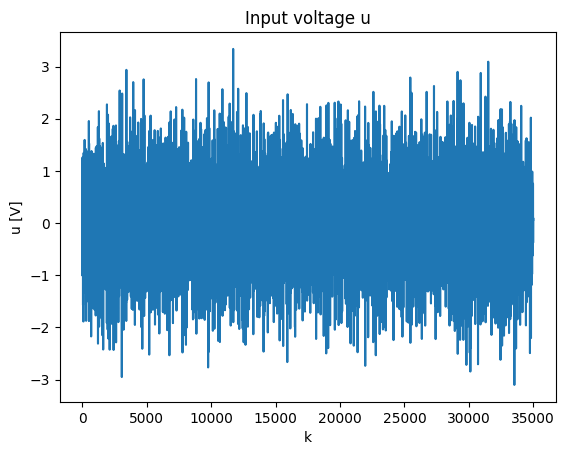

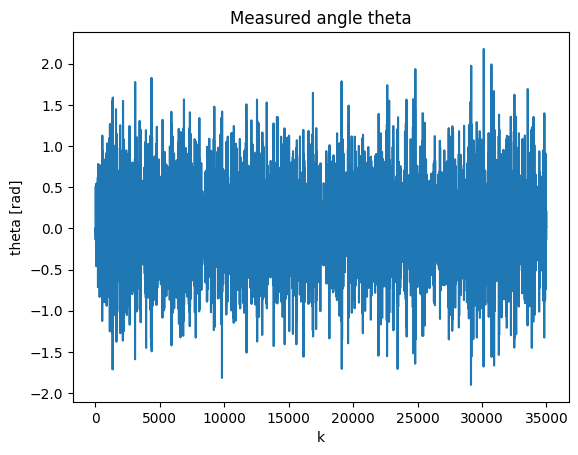

In [6]:
out = np.load("training-val-test-data.npz")

th = out["th"]   # measured disk angle
u = out["u"]     # applied input voltage

print("u shape:", u.shape)
print("th shape:", th.shape)

plt.figure()
plt.plot(u)
plt.title("Input voltage u")
plt.xlabel("k")
plt.ylabel("u [V]")
plt.show()

plt.figure()
plt.plot(th)
plt.title("Measured angle theta")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.show()


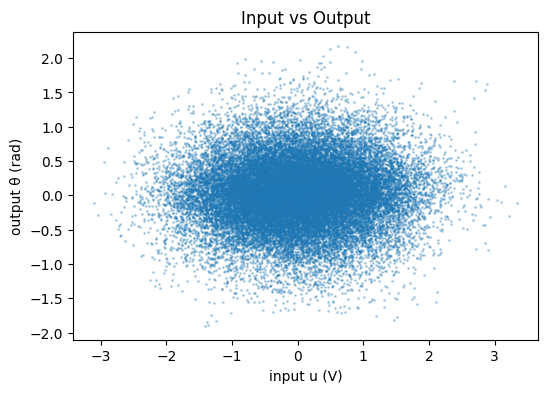

In [7]:
# scatter plot θ vs u 
plt.figure(figsize=(6,4))
plt.scatter(u, th, s=1, alpha=0.3)
plt.xlabel('input u (V)')
plt.ylabel('output θ (rad)')
plt.title('Input vs Output')
plt.show()

In [8]:
N = len(u)

N_train = int(0.7 * N)
N_val = int(0.15 * N)

u_train = u[:N_train]
th_train = th[:N_train]

u_val = u[N_train:N_train + N_val]
th_val = th[N_train:N_train + N_val]

u_test = u[N_train + N_val:]
th_test = th[N_train + N_val:]

print(len(u_train), len(u_val), len(u_test))

24500 5250 5250


In [9]:
u_mean = u_train.mean()
u_std = u_train.std()

th_mean = th_train.mean()
th_std = th_train.std()

u_train_n = (u_train - u_mean) / u_std
u_val_n = (u_val - u_mean) / u_std
u_test_n = (u_test - u_mean) / u_std

th_train_n = (th_train - th_mean) / th_std
th_val_n = (th_val - th_mean) / th_std
th_test_n = (th_test - th_mean) / th_std

print("u mean/std:", u_mean, u_std)
print("theta mean/std:", th_mean, th_std)

u mean/std: -2.687187240524085e-05 0.8410479397424789
theta mean/std: 0.03394048474666838 0.46785269160434234


## NARX Model

The first model is a nonlinear autoregressive model with exogenous input. It predicts the current angle using a finite number of previous angle and voltage samples. This is a simple neural-network structure, but it is suitable because the disk dynamics depend strongly on recent input-output history.

### NARX Implementation

The final reproducible implementation is stored in:

`narx_selected_export.py`

This script trains the selected NARX model with \(n_a=4\), \(n_b=5\), two hidden layers with 32 neurons, and ReLU activation. It evaluates the model on the validation and held-out test splits, saves report figures, and creates the final `.npz` submission files. The notebook keeps the main logic, tuning results, and discussion, while the Python script is used for clean reproducibility.

In [10]:
# because of the above output comes the 15
def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        X.append(np.concatenate([u[k-nb:k],y[k-na:k]]))
        Y.append(y[k])
    return np.array(X), np.array(Y)


### Hyperparameter Tuning

The lag orders `na` and `nb`, the hidden size, and the activation function were varied. The purpose was to check how much past history and network capacity were needed. The final model was chosen based on validation RMSE.

In [27]:
import itertools

# hyperparameters to tune
na_nb_values = [2, 4, 5, 6, 8, 10]  
hidden_sizes = [32, 64, 128]
activations = {'tanh': nn.Tanh(), 'relu': nn.ReLU()}

results = []

for na, nb, hidden_size, (act_name, act_fn) in itertools.product(
    na_nb_values, na_nb_values, hidden_sizes, activations.items()
):
    
    # data creation
    X_tr, Y_tr = create_IO_data(u_train_n, th_train_n, na, nb)
    X_val, Y_val = create_IO_data(u_val_n, th_val_n, na, nb)
    
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    Y_tr_t = torch.tensor(Y_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    Y_val_t = torch.tensor(Y_val, dtype=torch.float32)
    
    # model creation
    class NARXNet_tuning(nn.Module):
        def __init__(self, na, nb, hidden_size, act):
            super().__init__()
            self.fc1 = nn.Linear(na + nb, hidden_size)
            self.fc2 = nn.Linear(hidden_size, hidden_size)
            self.fc3 = nn.Linear(hidden_size, 1)
            self.act = act
        
        def forward(self, x):
            out = self.act(self.fc1(x))
            out = self.act(self.fc2(out))
            return self.fc3(out)
    set_seed()
    model = NARXNet_tuning(na, nb, hidden_size, act_fn)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    # train with early stopping
    best_val = float('inf')
    patience, counter = 20, 0
    
    for epoch in range(3000):  
        model.train()
        optimizer.zero_grad()
        pred = model(X_tr_t).squeeze()
        loss = torch.sqrt(criterion(pred, Y_tr_t))
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze()
            val_loss = torch.sqrt(criterion(val_pred, Y_val_t)).item()
        
        if val_loss < best_val:
            best_val = val_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break
        
    results.append({
        'na': na, 'nb': nb, 
        'hidden': hidden_size, 
        'activation': act_name,
        'val_rmse_norm': best_val,  # normalized
        'val_rmse_rad': best_val * th_std  
    })
    print(f'na={na}, nb={nb}, hidden={hidden_size}, act={act_name} → Val RMSE={best_val * th_std:.4f} rad')
    

# best model
best = min(results, key=lambda x: x['val_rmse_rad'])
print(f'\nBest: {best}')

na=2, nb=2, hidden=32, act=tanh → Val RMSE=0.0061 rad
na=2, nb=2, hidden=32, act=relu → Val RMSE=0.0048 rad
na=2, nb=2, hidden=64, act=tanh → Val RMSE=0.0070 rad
na=2, nb=2, hidden=64, act=relu → Val RMSE=0.0046 rad
na=2, nb=2, hidden=128, act=tanh → Val RMSE=0.0094 rad
na=2, nb=2, hidden=128, act=relu → Val RMSE=0.0048 rad
na=2, nb=4, hidden=32, act=tanh → Val RMSE=0.0054 rad
na=2, nb=4, hidden=32, act=relu → Val RMSE=0.0060 rad
na=2, nb=4, hidden=64, act=tanh → Val RMSE=0.0097 rad
na=2, nb=4, hidden=64, act=relu → Val RMSE=0.0056 rad
na=2, nb=4, hidden=128, act=tanh → Val RMSE=0.0100 rad
na=2, nb=4, hidden=128, act=relu → Val RMSE=0.0054 rad
na=2, nb=5, hidden=32, act=tanh → Val RMSE=0.0069 rad
na=2, nb=5, hidden=32, act=relu → Val RMSE=0.0066 rad
na=2, nb=5, hidden=64, act=tanh → Val RMSE=0.0089 rad
na=2, nb=5, hidden=64, act=relu → Val RMSE=0.0056 rad
na=2, nb=5, hidden=128, act=tanh → Val RMSE=0.0091 rad
na=2, nb=5, hidden=128, act=relu → Val RMSE=0.0064 rad
na=2, nb=6, hidden=32,

In [28]:
na, nb = 6, 2
hidden_size = 32

X_tr, Y_tr = create_IO_data(u_train_n, th_train_n, na, nb)
X_val, Y_val = create_IO_data(u_val_n, th_val_n, na, nb)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
Y_tr_t = torch.tensor(Y_tr, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

set_seed()
final_model = NARXNet_tuning(na, nb, hidden_size, nn.ReLU())
final_model.na = na
final_model.nb = nb
final_model.n0 = max(na, nb)

optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

train_losses = []
val_losses = []
best_val = float('inf')
patience, counter = 100, 0

for epoch in range(6000):
    final_model.train()
    optimizer.zero_grad()
    pred = final_model(X_tr_t).squeeze()
    loss = torch.sqrt(criterion(pred, Y_tr_t))
    loss.backward()
    optimizer.step()

    final_model.eval()
    with torch.no_grad():
        val_pred = final_model(X_val_t).squeeze()
        val_loss = torch.sqrt(criterion(val_pred, Y_val_t)).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(final_model.state_dict(), 'best_narx_final.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Train RMSE: {loss.item():.4f}, Val RMSE: {val_loss:.4f}')

final_model.load_state_dict(torch.load('best_narx_final.pth'))
print(f'Best Val RMSE: {best_val * th_std:.4f} rad')

Epoch 0, Train RMSE: 0.9432, Val RMSE: 0.9798
Epoch 100, Train RMSE: 0.0677, Val RMSE: 0.0729
Epoch 200, Train RMSE: 0.0328, Val RMSE: 0.0373
Epoch 300, Train RMSE: 0.0252, Val RMSE: 0.0281
Epoch 400, Train RMSE: 0.0192, Val RMSE: 0.0214
Epoch 500, Train RMSE: 0.0149, Val RMSE: 0.0167
Epoch 600, Train RMSE: 0.0120, Val RMSE: 0.0133
Epoch 700, Train RMSE: 0.0110, Val RMSE: 0.0121
Epoch 800, Train RMSE: 0.0096, Val RMSE: 0.0105
Epoch 900, Train RMSE: 0.0089, Val RMSE: 0.0097
Epoch 1000, Train RMSE: 0.0085, Val RMSE: 0.0093
Epoch 1100, Train RMSE: 0.0083, Val RMSE: 0.0090
Epoch 1200, Train RMSE: 0.0081, Val RMSE: 0.0088
Epoch 1300, Train RMSE: 0.0079, Val RMSE: 0.0085
Epoch 1400, Train RMSE: 0.0078, Val RMSE: 0.0084
Epoch 1500, Train RMSE: 0.0078, Val RMSE: 0.0082
Epoch 1600, Train RMSE: 0.0077, Val RMSE: 0.0081
Epoch 1700, Train RMSE: 0.0076, Val RMSE: 0.0080
Epoch 1800, Train RMSE: 0.0075, Val RMSE: 0.0079
Epoch 1900, Train RMSE: 0.0074, Val RMSE: 0.0078
Epoch 2000, Train RMSE: 0.0074, 

### Train & Validation Loss of best HP

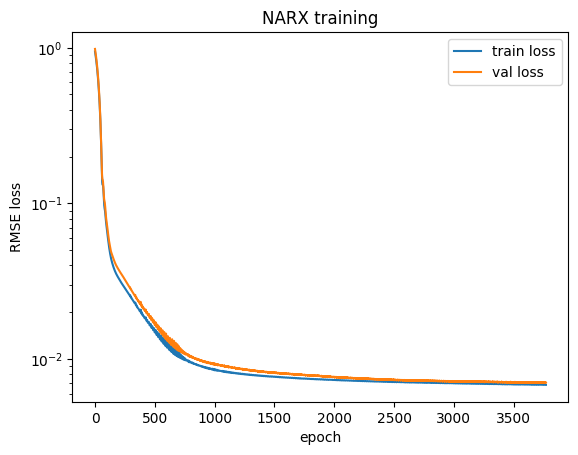

In [29]:
plt.figure()
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("RMSE loss")
plt.title("NARX training")
plt.legend()
plt.show()

The training curve shows that both the training and validation losses decrease as the number of epochs increases. The validation loss follows the training loss closely, which means that there is no clear sign of strong overfitting. After some epochs the improvement becomes smaller, so early stopping is useful to keep the best validation model.

### Residual Plots

The residual plot was used to check if the model makes errors with a clear pattern. Most residuals are close to zero, which means that the one-step prediction is accurate for most samples. Some larger errors still appear, especially when the disk motion changes faster. This is expected because these regions are harder to predict.

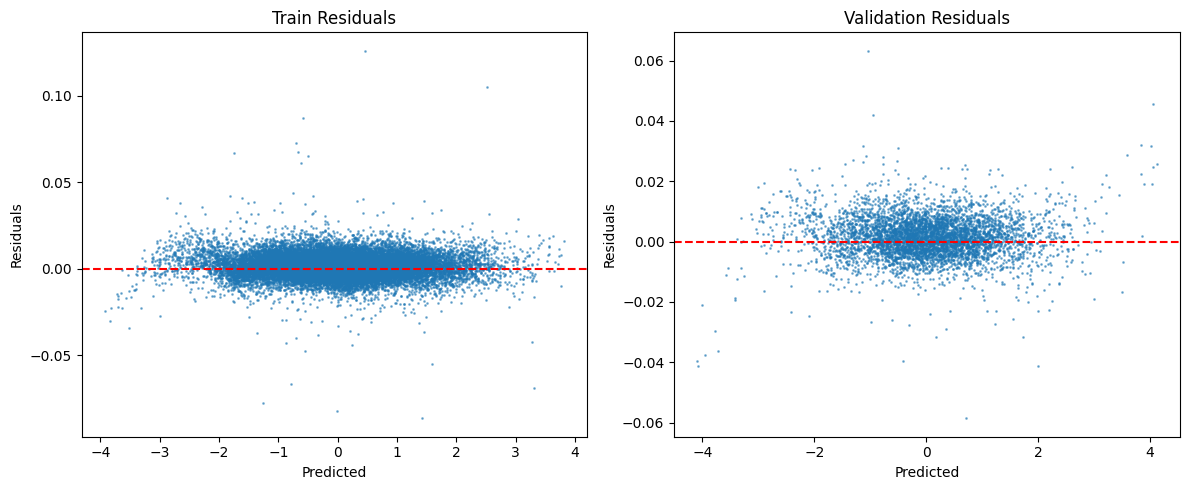

In [30]:
final_model.eval()
with torch.no_grad():
    Ytrain_pred = final_model(X_tr_t).squeeze()
    Yval_pred = final_model(X_val_t).squeeze()

train_residuals = (Y_tr_t - Ytrain_pred).numpy()
val_residuals = (Y_val_t - Yval_pred).numpy()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(Ytrain_pred.numpy(), train_residuals, alpha=0.5, s=1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Train Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
plt.scatter(Yval_pred.numpy(), val_residuals, alpha=0.5, s=1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Validation Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

### Simulation

Simulation RMS: 0.0547 rad
Simulation RMS: 3.13 deg
Simulation NRMS: 11.10%


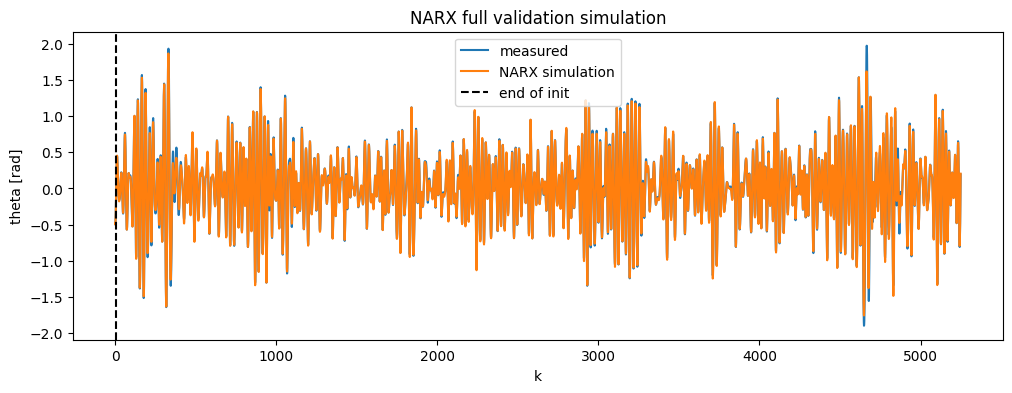

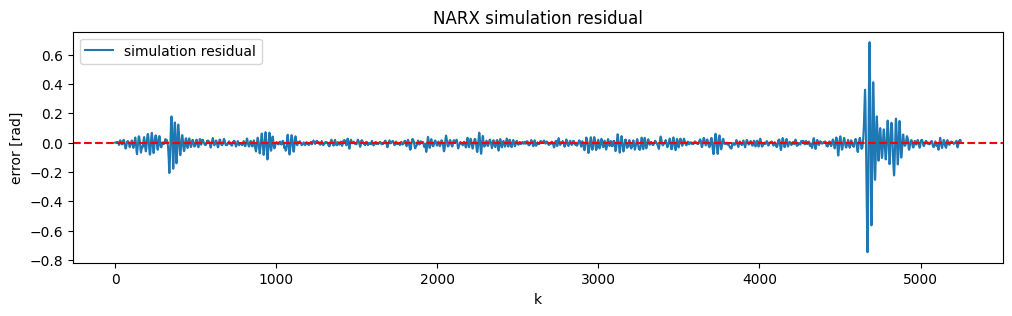

In [31]:
def simulate_narx_full(model, u_seq, y_seq, th_mean, th_std):
    """
    Full free-run simulation for NARX model.
    u_seq: normalized input, shape (N,)
    y_seq: normalized measured output, shape (N,)
    """
    model.eval()
    
    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)
    
    N = len(u_t)
    na = model.na
    nb = model.nb
    n0 = model.n0
    
    # initialize with true measured outputs
    y_generated = []
    for i in range(n0):
        y_generated.append(y_t[i])
    
    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = torch.stack(y_generated[t-na:t]).reshape(1, -1)
            x = torch.cat([u_lags, y_lags], dim=1)
            y_next = model(x).squeeze()
            y_generated.append(y_next)
    
    y_hat_n = torch.stack(y_generated).numpy()
    
    # denormalize
    y_hat = y_hat_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean
    
    return y_hat, y_true

# evaluation
th_val_sim, th_val_true = simulate_narx_full(
    final_model, u_val_n, th_val_n, th_mean, th_std
)

skip = final_model.n0
rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
rms_deg = rms / (2*np.pi) * 360
nrms = rms / np.std(th_val_true[skip:])

print(f"Simulation RMS: {rms:.4f} rad")
print(f"Simulation RMS: {rms_deg:.2f} deg")
print(f"Simulation NRMS: {nrms*100:.2f}%")

# plots
plt.figure(figsize=(12, 4))
plt.plot(th_val_true, label="measured")
plt.plot(th_val_sim, label="NARX simulation")
plt.axvline(skip, color="black", linestyle="--", label="end of init")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("NARX full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_sim - th_val_true, label="simulation residual")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("NARX simulation residual")
plt.legend()
plt.show()

In free-run simulation the model uses its own previous predictions as inputs. Because of this, the task is harder than one-step prediction. The simulation follows the main measured trajectory, but the residual plot shows some local peaks. These peaks show moments where small errors are fed back into the model and temporarily increase.

### One step prediction

In [32]:
def one_step_prediction_narx(model, u_seq, y_seq, th_mean, th_std):
    model.eval()
    
    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)
    
    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb
    
    y_pred = []
    for i in range(n0):
        y_pred.append(y_t[i])
    
    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = y_t[t-na:t].reshape(1, -1)
            x = torch.cat([u_lags, y_lags], dim=1)
            y_next = model(x).squeeze()  # ← model(x) όχι model.net(x)
            y_pred.append(y_next)
    
    y_pred_n = torch.stack(y_pred).numpy()
    y_pred_denorm = y_pred_n * th_std + th_mean
    y_true_denorm = y_seq * th_std + th_mean
    
    return y_pred_denorm, y_true_denorm

# evaluation
th_val_pred, th_val_true_pred = one_step_prediction_narx(
    final_model, u_val_n, th_val_n, th_mean, th_std
)

skip = final_model.n0
pred_rms = np.sqrt(np.mean((th_val_pred[skip:] - th_val_true_pred[skip:])**2))
pred_rms_deg = pred_rms / (2*np.pi) * 360
pred_nrms = pred_rms / np.std(th_val_true_pred[skip:])

print(f"One-step prediction RMS: {pred_rms:.4f} rad")
print(f"One-step prediction RMS: {pred_rms_deg:.2f} deg")
print(f"One-step prediction NRMS: {pred_nrms*100:.2f}%")

One-step prediction RMS: 0.0033 rad
One-step prediction RMS: 0.19 deg
One-step prediction NRMS: 0.67%


### One step prediction in the hidden test file

In [33]:
# load hidden test file
data = np.load('hidden-test-prediction-submission-file.npz')
upast_test = data['upast']    # (645, 15)
thpast_test = data['thpast']  # (645, 15)

# normalize train stats
upast_test_norm = (upast_test - u_mean) / u_std
thpast_test_norm = (thpast_test - th_mean) / th_std

# keep only last nb=2 and na=5
upast_test_norm_cropped = upast_test_norm[:, -nb:]   # (645, 2)
thpast_test_norm_cropped = thpast_test_norm[:, -na:]  # (645, 5)

# create X_test
X_test = np.concatenate([upast_test_norm_cropped, thpast_test_norm_cropped], axis=1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

# prediction
final_model.eval()
with torch.no_grad():
    y_pred_norm = final_model(X_test_t).squeeze().numpy()

# denormalize
y_pred = y_pred_norm * th_std + th_mean

# save
save_dict = {k: data[k] for k in data.files}
save_dict["thnow"] = y_pred
np.savez("prediction_submission_final.npz", **save_dict)
print('Saved!')

Saved!


### Simulation in the test file

In [34]:
# load hidden test simulation file
sim_data = np.load('hidden-test-simulation-submission-file.npz')
u_sim = sim_data['u']    # (5000,)
th_sim = sim_data['th']  # (5000,) 

# normalize with train stats
u_sim_norm = (u_sim - u_mean) / u_std
th_sim_norm = (th_sim - th_mean) / th_std  

# free run simulation
n0 = final_model.n0  # max(na, nb) = max(5,2) = 5

y_generated = []

# initialization with true measured outputs
for i in range(n0):
    y_generated.append(torch.tensor(th_sim_norm[i], dtype=torch.float32))

final_model.eval()
with torch.no_grad():
    for t in range(n0, len(u_sim)):
        u_lags = torch.tensor(u_sim_norm[t-nb:t], dtype=torch.float32).reshape(1, -1)
        y_lags = torch.stack(y_generated[t-na:t]).reshape(1, -1)
        x = torch.cat([u_lags, y_lags], dim=1)
        y_next = final_model(x).squeeze()
        y_generated.append(y_next)

# denormalize
y_hat_norm = torch.stack(y_generated).numpy()
y_hat = y_hat_norm * th_std + th_mean

# save
save_dict_sim = {'u': u_sim, 'th': y_hat}
np.savez('simulation_submission_final.npz', **save_dict_sim)
print('Saved!')
print(f'Min: {y_hat.min():.4f}, Max: {y_hat.max():.4f}')

Saved!
Min: -1.9222, Max: 2.0808


### NFIR Attempt

An NFIR structure was also tested as an initial baseline. However, because it only uses past inputs and does not use past output measurements, its performance was worse than the selected NARX and LSTM models. Therefore, it was not selected for the final comparison.

## Long Short-Term Memory Model

The LSTM was tested as the advanced recurrent neural-network model. In contrast to the NARX model, where the number of past samples is manually selected, the LSTM processes a full sequence and stores information in an internal hidden state.

For each time step, the input vector is:

\[
x_k = [u_k, \sin(\theta_k), \cos(\theta_k)]
\]

The voltage is normalized using the training-set mean and standard deviation. The angle is not normalized before applying sine and cosine, because this would destroy the periodic geometry of the angle.

### LSTM Implementation

The final reproducible implementation is stored in:

`lstm_selected_export.py`

This script trains the selected standard LSTM, evaluates it on the validation and held-out test splits, saves report figures, and creates the final `.npz` submission files. The notebook keeps the main logic, tuning results, and discussion, while the Python script is used for clean reproducibility.

In [19]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path("/Users/emmanouilalatserakis/gym-unbalanced-disk/disc-benchmark-files")
FIG_DIR = BASE_DIR / "Figures"

metrics_path = BASE_DIR / "selected_lstm_metrics.json"

### Selected Standard LSTM Architecture

The selected standard LSTM uses a sequence length of 100 samples. Each sequence contains the normalized voltage and the sine-cosine representation of the angle. The LSTM output is passed through a small fully connected head, producing two outputs:

\[
[\widehat{\sin(\theta_k)}, \widehat{\cos(\theta_k)}]
\]

The predicted vector is normalized and converted back to an angle using `atan2`.

In [ ]:
selected_lstm_config = {
    "seq_len": 100,
    "hidden_size": 64,
    "num_layers": 1,
    "dense_size": 32,
    "dropout": 0.0,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "patience": 20,
}

pd.DataFrame(
    selected_lstm_config.items(),
    columns=["Parameter", "Selected value"]
)

### Hyperparameter Tuning

The first tuning step changed the number of hidden units and the number of LSTM layers. The aim was to check whether a larger or deeper recurrent model improved the validation performance. The one-layer LSTMs were clearly better for free-run simulation, while the two-layer LSTMs gave much worse simulation results.

In [20]:
lstm_arch_tuning = pd.DataFrame([
    {"Hidden": 64, "Layers": 1, "Seq. length": 100, "Prediction RMSE [rad]": 0.00874, "Simulation RMSE [rad]": 0.02588},
    {"Hidden": 128, "Layers": 1, "Seq. length": 100, "Prediction RMSE [rad]": 0.00866, "Simulation RMSE [rad]": 0.02680},
    {"Hidden": 64, "Layers": 2, "Seq. length": 100, "Prediction RMSE [rad]": 0.03775, "Simulation RMSE [rad]": 0.41428},
    {"Hidden": 128, "Layers": 2, "Seq. length": 100, "Prediction RMSE [rad]": 0.03895, "Simulation RMSE [rad]": 0.45110},
])

lstm_arch_tuning

,Hidden,Layers,Seq. length,Prediction RMSE [rad],Simulation RMSE [rad]
0,64,1,100,0.00874,0.02588
1,128,1,100,0.00866,0.02680
2,64,2,100,0.03775,0.41428
3,128,2,100,0.03895,0.45110


The sequence length was also varied. Shorter sequences did not contain enough history for the best simulation result. A sequence length of 100 gave the lowest simulation RMSE, while increasing the length to 150 did not improve the model.

In [21]:
seq_len_tuning = pd.DataFrame([
    {"Sequence length": 30, "Prediction RMSE [rad]": 0.00945, "Simulation RMSE [rad]": 0.03671},
    {"Sequence length": 50, "Prediction RMSE [rad]": 0.01024, "Simulation RMSE [rad]": 0.03352},
    {"Sequence length": 75, "Prediction RMSE [rad]": 0.01007, "Simulation RMSE [rad]": 0.02779},
    {"Sequence length": 100, "Prediction RMSE [rad]": 0.00874, "Simulation RMSE [rad]": 0.02588},
    {"Sequence length": 150, "Prediction RMSE [rad]": 0.00983, "Simulation RMSE [rad]": 0.03409},
])

seq_len_tuning

,Sequence length,Prediction RMSE [rad],Simulation RMSE [rad]
0,30,0.00945,0.03671
1,50,0.01024,0.03352
2,75,0.01007,0.02779
3,100,0.00874,0.02588
4,150,0.00983,0.03409


### Final Standard LSTM Results

The selected standard LSTM was then evaluated on the validation split and on the held-out test split. The simulation RMSE is reported after the initialization samples, because the first samples are measured and used to start the rollout.

In [22]:
with open(metrics_path, "r") as f:
    lstm_metrics = json.load(f)

standard_lstm_results = pd.DataFrame([
    {
        "Case": "Validation prediction",
        "RMSE [rad]": lstm_metrics["validation_prediction_rmse_rad"],
        "RMSE [deg]": lstm_metrics["validation_prediction_rmse_deg"],
    },
    {
        "Case": "Validation simulation",
        "RMSE [rad]": lstm_metrics["validation_simulation_rmse_rad_after_init"],
        "RMSE [deg]": lstm_metrics["validation_simulation_rmse_deg_after_init"],
    },
    {
        "Case": "Test prediction",
        "RMSE [rad]": lstm_metrics["test_prediction_rmse_rad"],
        "RMSE [deg]": lstm_metrics["test_prediction_rmse_deg"],
    },
    {
        "Case": "Test simulation",
        "RMSE [rad]": lstm_metrics["test_simulation_rmse_rad_after_init"],
        "RMSE [deg]": lstm_metrics["test_simulation_rmse_deg_after_init"],
    },
])

standard_lstm_results

,Case,RMSE [rad],RMSE [deg]
0,Validation prediction,0.008819,0.505311
1,Validation simulation,0.024952,1.429652
2,Test prediction,0.014531,0.832562
3,Test simulation,0.040964,2.347093


The standard LSTM performs best in free-run simulation. Its validation simulation RMSE is lower than the supplied good neural-network simulation benchmark. However, the one-step prediction RMSE is worse than the linear prediction benchmark. This shows that the standard LSTM is mainly useful for recursive simulation, not for one-step prediction.

The following figures show the training behavior and the free-run validation simulation of the selected standard LSTM model.

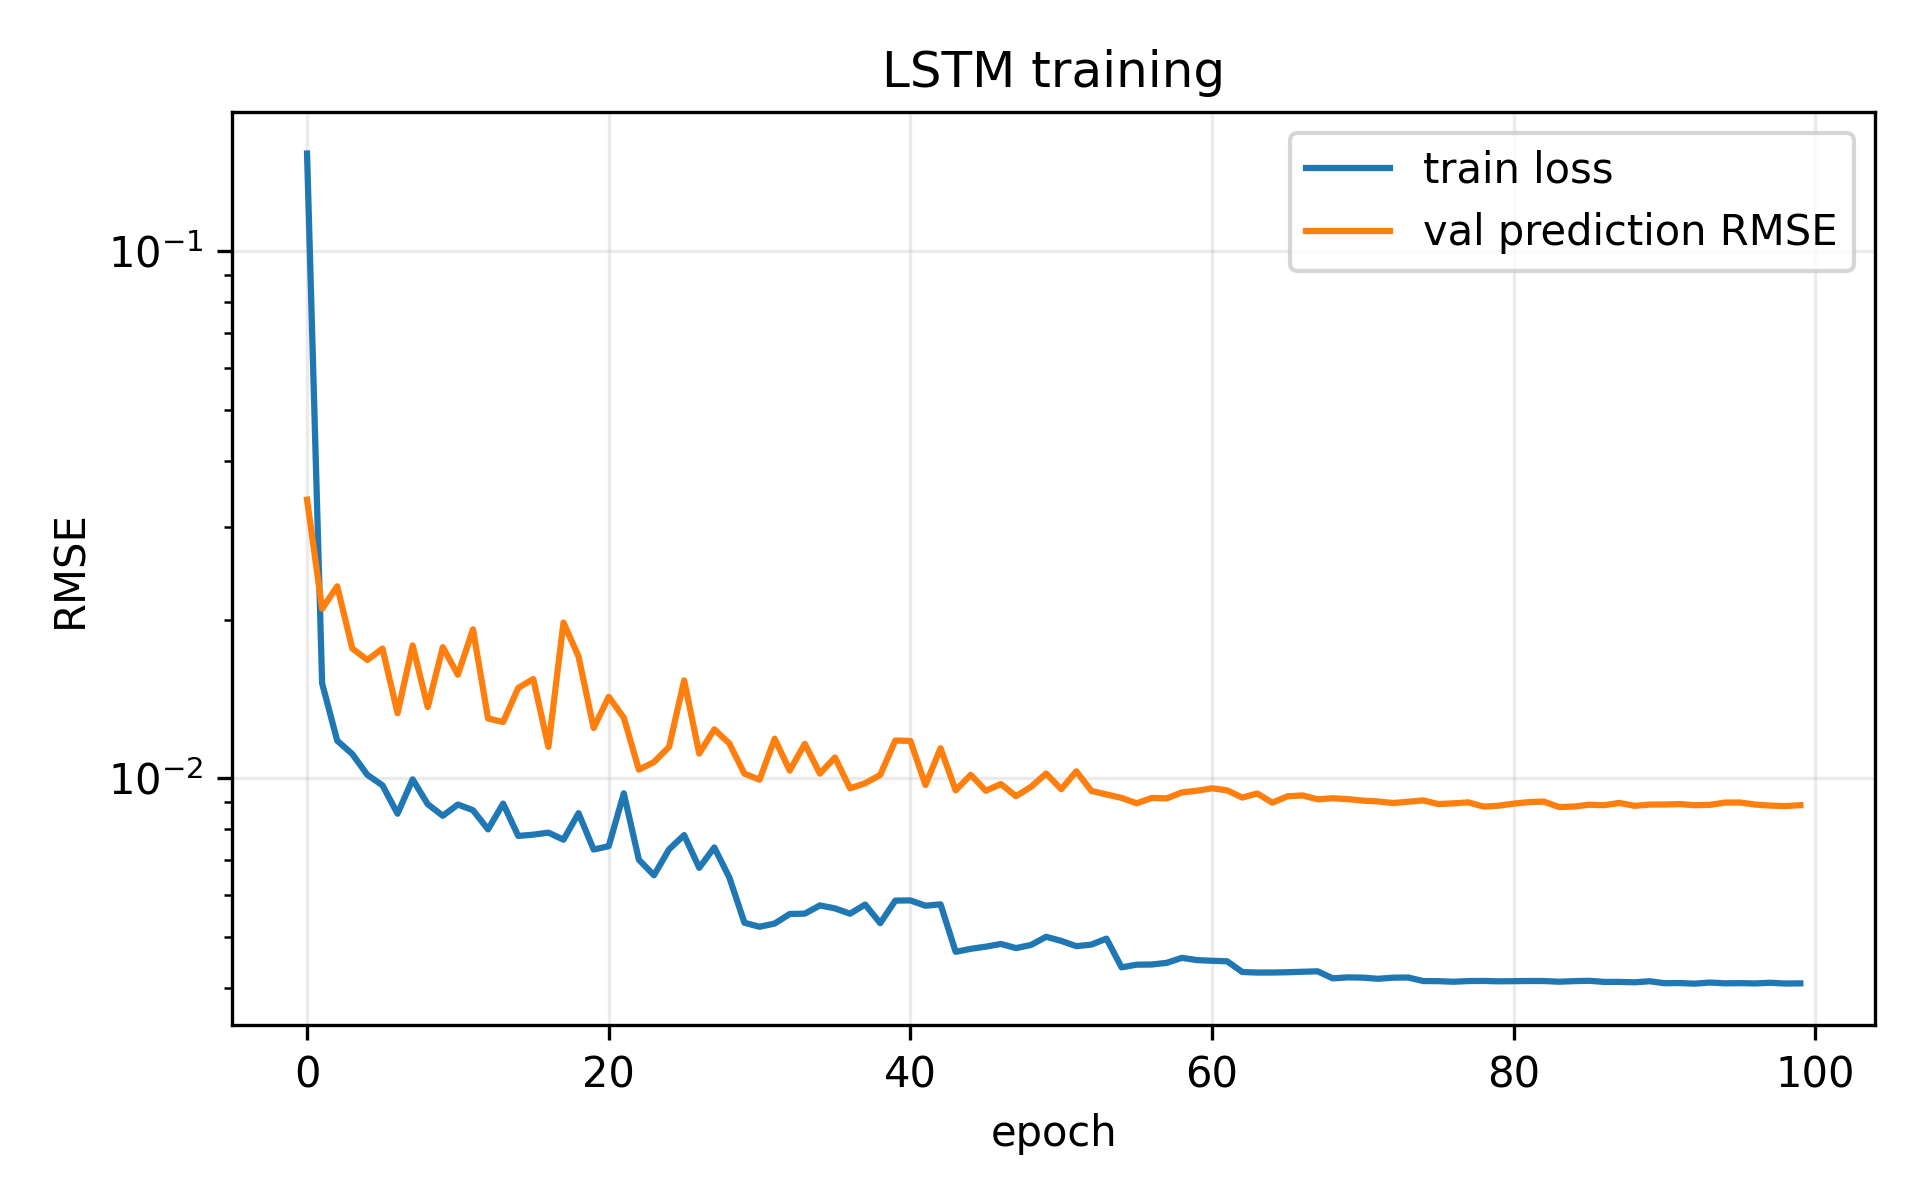

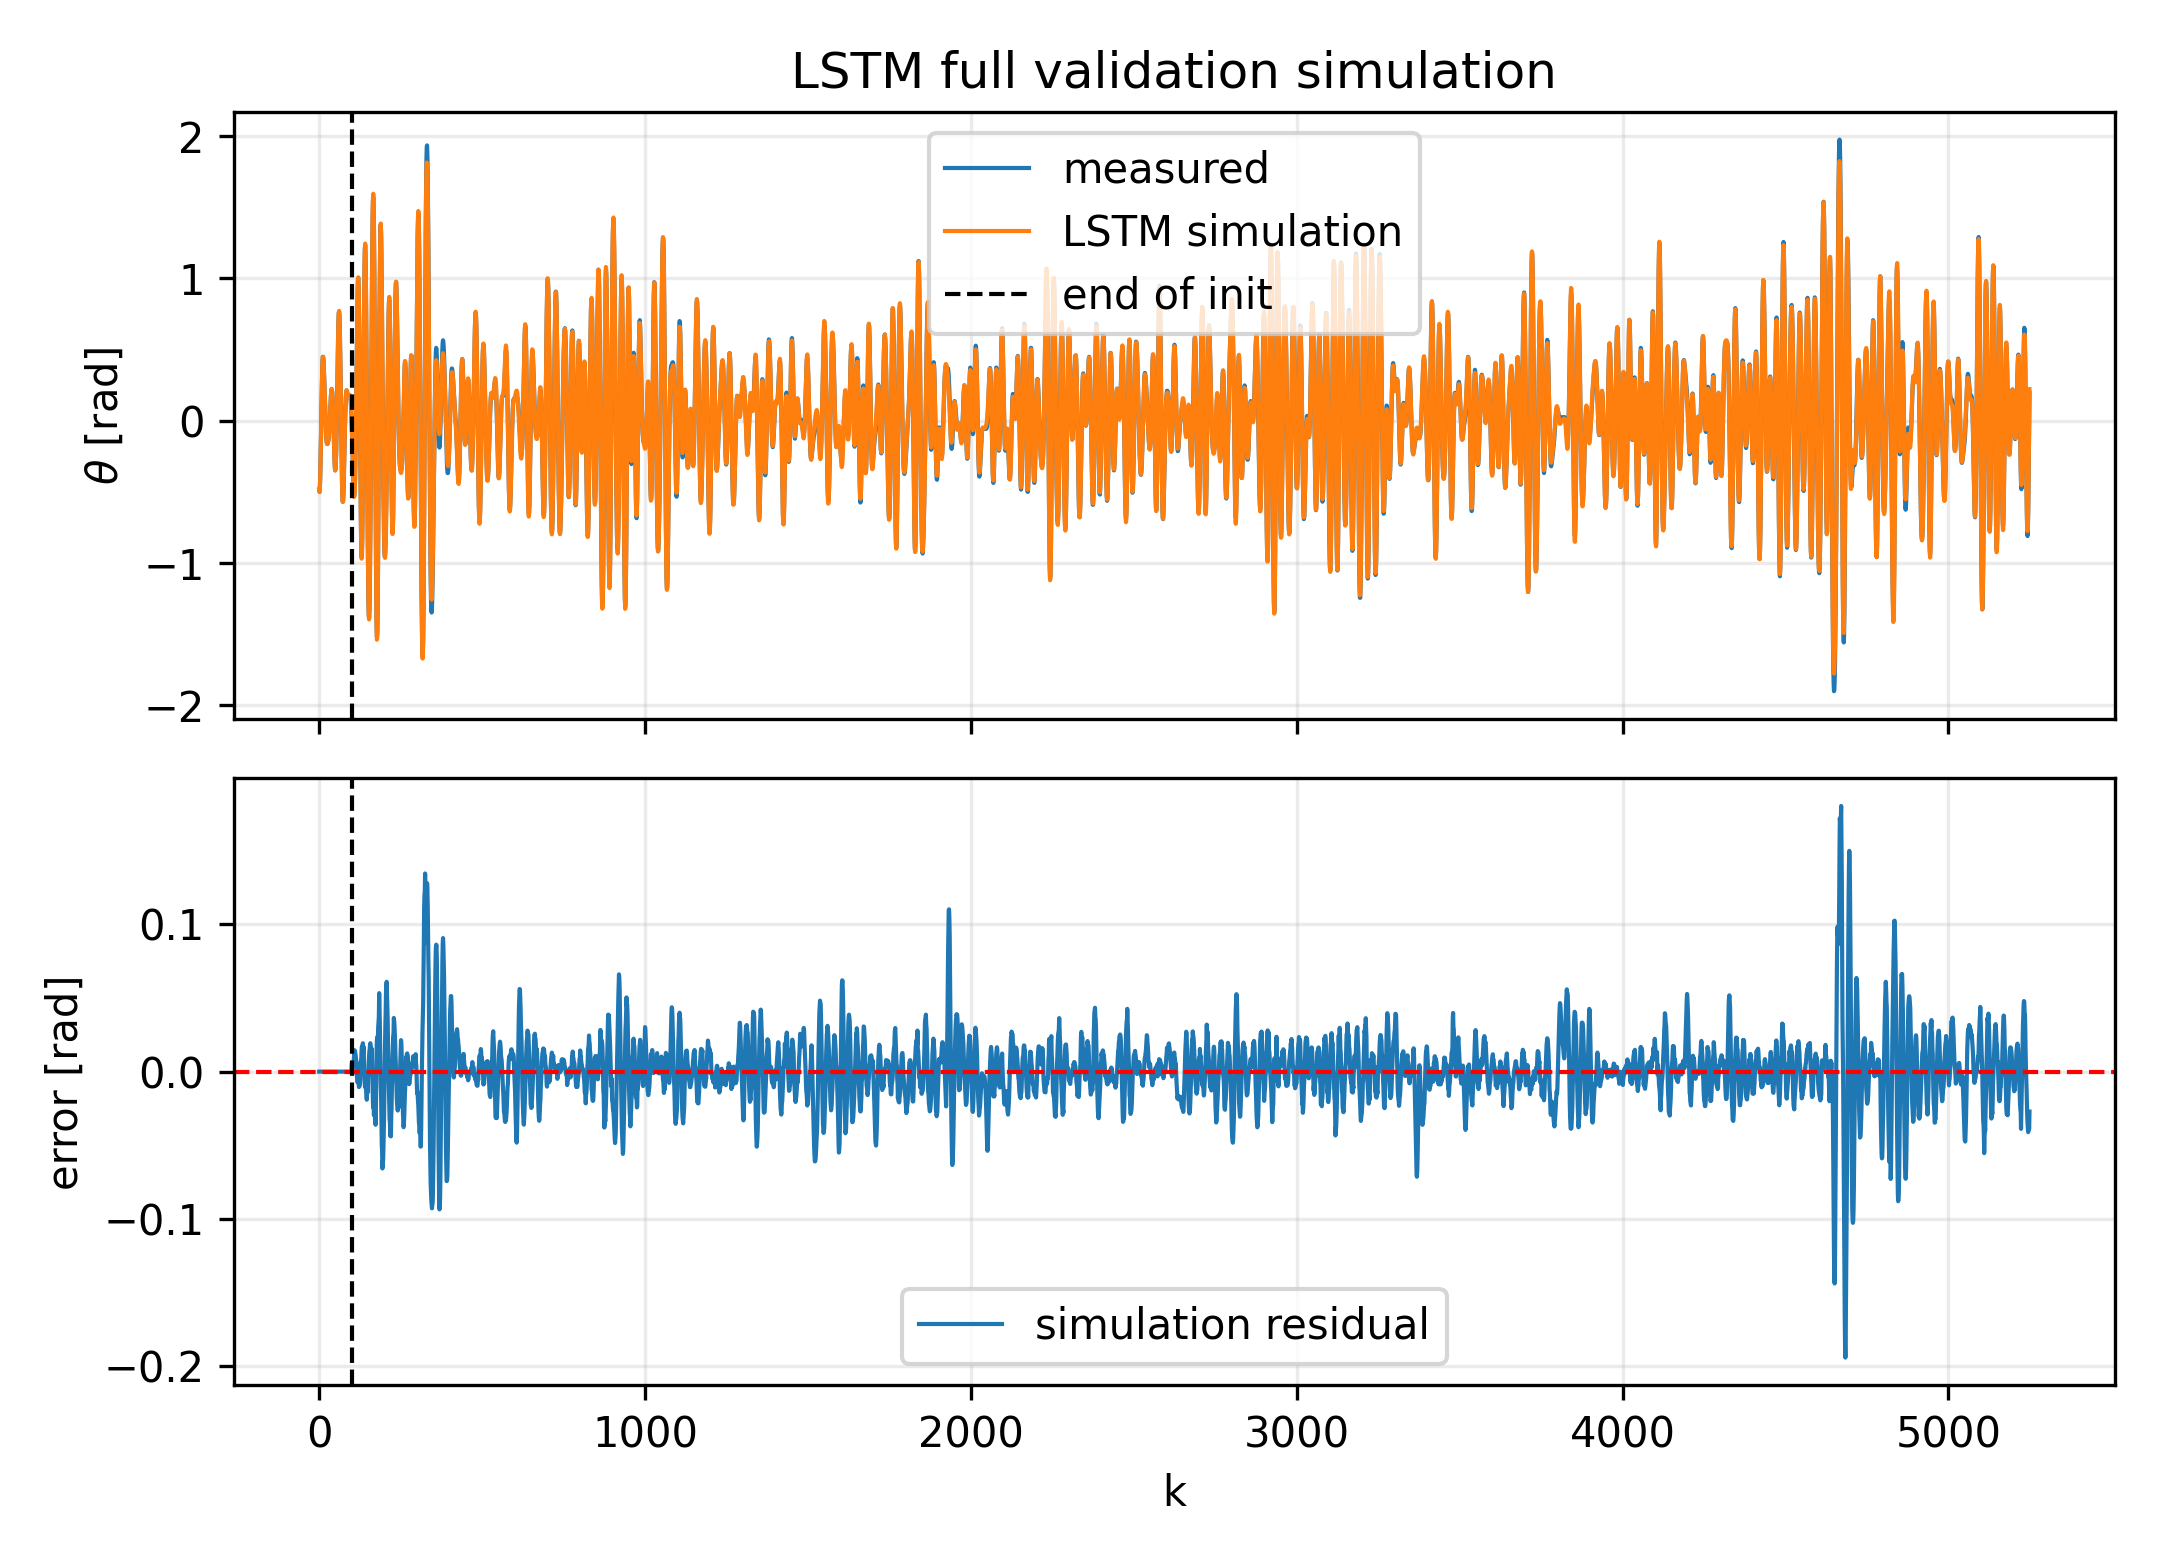

In [23]:
display(Image(filename=str(FIG_DIR / "LSTM_training_plot_lines.png")))
display(Image(filename=str(FIG_DIR / "LSTM_simulation_and_residual.png")))

The training curve shows that the validation RMSE decreases during training and then reaches a plateau. The free-run simulation shows that the LSTM follows the measured angle well over the validation sequence. The residual is mostly centered around zero, but some local peaks remain when the motion becomes more difficult to predict.

### Residual LSTM

A residual LSTM was also tested to improve one-step prediction. Instead of predicting the next sine-cosine output completely from scratch, the model predicts a correction from the last sine-cosine value in the input sequence:

\[
\hat{y}_k = y_{k-1} + \Delta y_k
\]

where \(y_k = [\sin(\theta_k), \cos(\theta_k)]^\top\). This is reasonable because the disk angle changes smoothly between two consecutive samples.

In [24]:
residual_lstm_results = pd.DataFrame([
    {"Model": "Linear benchmark", "Prediction RMSE [rad]": 0.00665, "Simulation RMSE [rad]": 0.25500},
    {"Model": "Good NN benchmark", "Prediction RMSE [rad]": 0.00382, "Simulation RMSE [rad]": 0.02710},
    {"Model": "Standard LSTM", "Prediction RMSE [rad]": 0.00874, "Simulation RMSE [rad]": 0.02588},
    {"Model": "Residual LSTM", "Prediction RMSE [rad]": 0.00527, "Simulation RMSE [rad]": 0.05061},
])

residual_lstm_results

,Model,Prediction RMSE [rad],Simulation RMSE [rad]
0,Linear benchmark,0.00665,0.25500
1,Good NN benchmark,0.00382,0.02710
2,Standard LSTM,0.00874,0.02588
3,Residual LSTM,0.00527,0.05061


The residual LSTM improves one-step prediction compared with the standard LSTM and also beats the linear benchmark in prediction. However, its free-run simulation result is worse than the standard LSTM. Therefore, the standard LSTM was kept as the best LSTM model for simulation, while the residual LSTM was useful as a balanced variant.

### Submission File Generation

The hidden submission templates are only used at the end to create files with the required format. They are not used for training, validation, or model selection.

The final files generated by `lstm_selected_export.py` are:

- `lstm_prediction_submission.npz`
- `lstm_simulation_submission.npz`

In [25]:
print("Prediction submission:", (BASE_DIR / "lstm_prediction_submission.npz").exists())
print("Simulation submission:", (BASE_DIR / "lstm_simulation_submission.npz").exists())
print("Checkpoint:", (BASE_DIR / "selected_lstm_best.pt").exists())

Prediction submission: True
Simulation submission: True
Checkpoint: True
